--- Step 1: Data Loaded Successfully! ---


,gender,age,Investment_Avenues,Mutual_Funds,Equity_Market,Debentures,Government_Bonds,Fixed_Deposits,PPF,Gold,...,Duration,Invest_Monitor,Expect,Avenue,What are your savings objectives?,Reason_Equity,Reason_Mutual,Reason_Bonds,Reason_FD,Source
0,Female,34,Yes,1,2,5,3,7,6,4,...,1-3 years,Monthly,20%-30%,Mutual Fund,Retirement Plan,Capital Appreciation,Better Returns,Safe Investment,Fixed Returns,Newspapers and Magazines
1,Female,23,Yes,4,3,2,1,5,6,7,...,More than 5 years,Weekly,20%-30%,Mutual Fund,Health Care,Dividend,Better Returns,Safe Investment,High Interest Rates,Financial Consultants
2,Male,30,Yes,3,6,4,2,5,1,7,...,3-5 years,Daily,20%-30%,Equity,Retirement Plan,Capital Appreciation,Tax Benefits,Assured Returns,Fixed Returns,Television
3,Male,22,Yes,2,1,3,7,6,4,5,...,Less than 1 year,Daily,10%-20%,Equity,Retirement Plan,Dividend,Fund Diversification,Tax Incentives,High Interest Rates,Internet
4,Female,24,No,2,1,3,6,4,5,7,...,Less than 1 year,Daily,20%-30%,Equity,Retirement Plan,Capital Appreciation,Better Returns,Safe Investment,Risk Free,Internet



--- Step 2: Dataset Info & Summary ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 24 columns):
 #   Column                             Non-Null Count  Dtype 
---  ------                             --------------  ----- 
 0   gender                             40 non-null     object
 1   age                                40 non-null     int64 
 2   Investment_Avenues                 40 non-null     object
 3   Mutual_Funds                       40 non-null     int64 
 4   Equity_Market                      40 non-null     int64 
 5   Debentures                         40 non-null     int64 
 6   Government_Bonds                   40 non-null     int64 
 7   Fixed_Deposits                     40 non-null     int64 
 8   PPF                                40 non-null     int64 
 9   Gold                               40 non-null     int64 
 10  Stock_Marktet                      40 non-null     object
 11  Factor                           

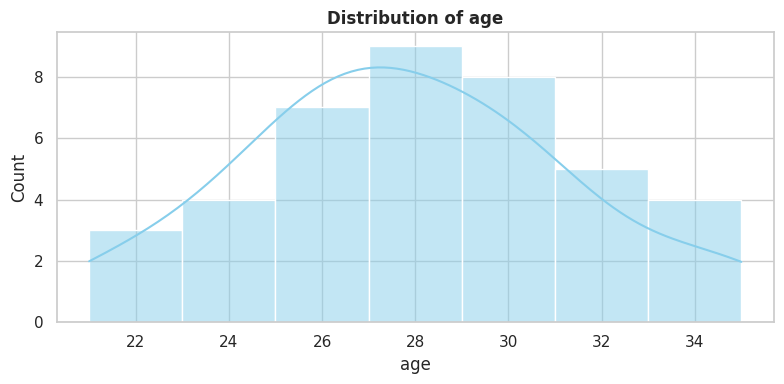

/tmp/ipykernel_1778/2242890996.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cats.values, y=top_cats.index, palette='viridis')


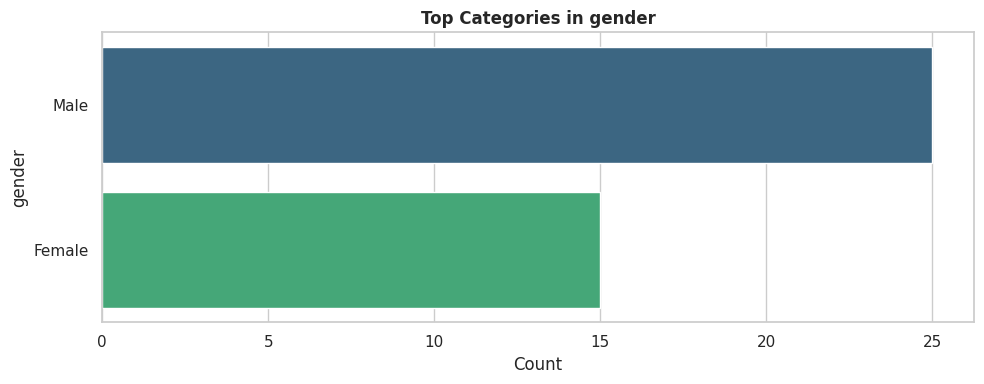

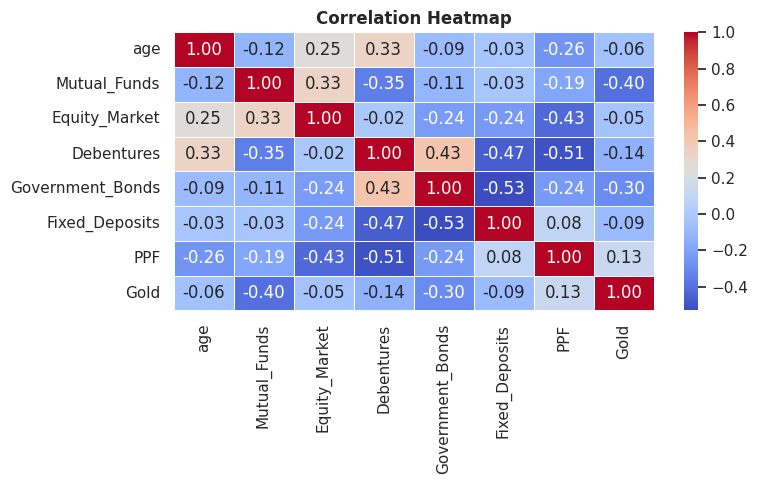


=== PHASE 2 SUMMARY & KEY INSIGHTS ===
1. Data Integrity: Removed duplicate entries and imputed missing values across numeric and categorical features.
2. Numeric Metric: 'age' has an average (mean) value of 27.80 with a median of 27.00.
3. Category Dominance: The most frequent value for 'gender' is 'Male'.


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style for plots
sns.set_theme(style="whitegrid")

# ==========================================
# STEP 1: LOAD DATASET
# ==========================================
# Your exact copied file path
file_path = '/investment - Copy.csv'

# Load the CSV file
df = pd.read_csv(file_path)

print("--- Step 1: Data Loaded Successfully! ---")
display(df.head())

# ==========================================
# STEP 2: EXPLORE DATA
# ==========================================
print("\n--- Step 2: Dataset Info & Summary ---")
df.info()

print("\n--- Initial Missing Values Count ---")
print(df.isnull().sum())

print(f"\n--- Initial Row Count: {df.shape[0]} | Column Count: {df.shape[1]} ---")

# ==========================================
# STEP 3: CLEAN DATA
# ==========================================
# 1. Remove duplicate rows
df = df.drop_duplicates()

# 2. Identify numeric and categorical columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

# 3. Fill missing numeric values with median
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

# 4. Fill missing categorical values with mode & strip trailing whitespace
for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])
    df[col] = df[col].astype(str).str.strip()

print("\n--- Step 3: Missing Values After Cleaning ---")
print(df.isnull().sum())

# ==========================================
# STEP 4: VISUALIZATIONS
# ==========================================
print("\n--- Step 4: Generating Visualizations ---")

# Chart 1: Histogram for first numeric variable
if len(numeric_cols) > 0:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[numeric_cols[0]], kde=True, color='skyblue')
    plt.title(f'Distribution of {numeric_cols[0]}', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Chart 2: Bar chart for top categories in first categorical variable
if len(categorical_cols) > 0:
    plt.figure(figsize=(10, 4))
    top_cats = df[categorical_cols[0]].value_counts().head(10)
    sns.barplot(x=top_cats.values, y=top_cats.index, palette='viridis')
    plt.title(f'Top Categories in {categorical_cols[0]}', fontsize=12, fontweight='bold')
    plt.xlabel('Count')
    plt.ylabel(categorical_cols[0])
    plt.tight_layout()
    plt.show()

# Chart 3: Correlation Heatmap
if len(numeric_cols) > 1:
    plt.figure(figsize=(8, 5))
    sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
    plt.title('Correlation Heatmap', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

# ==========================================
# STEP 5: SUMMARY INSIGHTS
# ==========================================
print("\n=== PHASE 2 SUMMARY & KEY INSIGHTS ===")
print("1. Data Integrity: Removed duplicate entries and imputed missing values across numeric and categorical features.")
if len(numeric_cols) > 0:
    print(f"2. Numeric Metric: '{numeric_cols[0]}' has an average (mean) value of {df[numeric_cols[0]].mean():.2f} with a median of {df[numeric_cols[0]].median():.2f}.")
if len(categorical_cols) > 0:
    print(f"3. Category Dominance: The most frequent value for '{categorical_cols[0]}' is '{df[categorical_cols[0]].mode()[0]}'.")